In [5]:
# ==================== CELL 1: آموزش مدل پایه DFE ====================
# این سلول را جداگانه اجرا کنید - فقط یک بار برای آموزش مدل

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import os
import math
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==================== کد اصلی DFE (بدون تغییر در الگوریتم) ====================

class DFEBackbone(nn.Module):
    def __init__(self, input_channels=1, embedding_dim=256, input_features=81):
        super(DFEBackbone, self).__init__()
        self.input_features = input_features
        self.input_size = self._calculate_input_size(input_features)
        
        self.conv1 = nn.Conv2d(input_channels, 64, kernel_size=3, padding=1, stride=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=1, stride=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1, stride=2)
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1, stride=1)
        self.bn4 = nn.BatchNorm2d(64)
        
        self.conv5 = nn.Conv2d(64, 64, kernel_size=3, padding=1, stride=1)
        self.bn5 = nn.BatchNorm2d(64)
        
        self.conv6 = nn.Conv2d(64, 128, kernel_size=3, padding=1, stride=2)
        self.bn6 = nn.BatchNorm2d(128)
        self.conv7 = nn.Conv2d(128, 128, kernel_size=3, padding=1, stride=1)
        self.bn7 = nn.BatchNorm2d(128)
        
        self.conv8 = nn.Conv2d(128, 128, kernel_size=3, padding=1, stride=1)
        self.bn8 = nn.BatchNorm2d(128)
        self.conv9 = nn.Conv2d(128, 128, kernel_size=3, padding=1, stride=1)
        self.bn9 = nn.BatchNorm2d(128)
        
        self.conv10 = nn.Conv2d(128, 256, kernel_size=3, padding=1, stride=2)
        self.bn10 = nn.BatchNorm2d(256)
        self.conv11 = nn.Conv2d(256, 256, kernel_size=3, padding=1, stride=1)
        self.bn11 = nn.BatchNorm2d(256)
        self.conv12 = nn.Conv2d(256, 256, kernel_size=3, padding=1, stride=1)
        self.bn12 = nn.BatchNorm2d(256)
        self.conv13 = nn.Conv2d(256, 256, kernel_size=3, padding=1, stride=1)
        self.bn13 = nn.BatchNorm2d(256)
        
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc1 = nn.Linear(256, 256)
        self.fc2 = nn.Linear(256, embedding_dim)
        self.relu = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(0.5)
        
        self.res1 = nn.Sequential(nn.Conv2d(input_channels, 64, kernel_size=1, stride=1), nn.BatchNorm2d(64))
        self.res2 = nn.Sequential(nn.Conv2d(64, 64, kernel_size=1, stride=2), nn.BatchNorm2d(64))
        self.res4 = nn.Sequential(nn.Conv2d(64, 128, kernel_size=1, stride=2), nn.BatchNorm2d(128))
        self.res6 = nn.Sequential(nn.Conv2d(128, 256, kernel_size=1, stride=2), nn.BatchNorm2d(256))
        
        self._initialize_weights()
        
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
    
    def _calculate_input_size(self, num_features):
        sqrt = math.isqrt(num_features)
        if sqrt * sqrt == num_features:
            return sqrt
        return sqrt + 1
    
    def forward(self, x, return_features=False):
        features = []
        
        x1 = self.relu(self.bn1(self.conv1(x)))
        x1 = self.relu(self.bn2(self.conv2(x1)))
        x1 = x1 + self.res1(x)
        features.append(x1)
        
        x2 = self.relu(self.bn3(self.conv3(x1)))
        x2 = self.relu(self.bn4(self.conv4(x2)))
        x2 = x2 + self.res2(x1)
        features.append(x2)
        
        x3 = self.relu(self.bn5(self.conv5(x2)))
        x3 = x3 + x2
        features.append(x3)
        
        x4 = self.relu(self.bn6(self.conv6(x3)))
        x4 = self.relu(self.bn7(self.conv7(x4)))
        x4 = x4 + self.res4(x2)
        features.append(x4)
        
        x5 = self.relu(self.bn8(self.conv8(x4)))
        x5 = self.relu(self.bn9(self.conv9(x5)))
        x5 = x5 + x4
        features.append(x5)
        
        x6 = self.relu(self.bn10(self.conv10(x5)))
        x6 = self.relu(self.bn11(self.conv11(x6)))
        x6 = self.relu(self.bn12(self.conv12(x6)))
        x6 = self.relu(self.bn13(self.conv13(x6)))
        x6 = x6 + self.res6(x4)
        features.append(x6)
        
        x_pool = self.adaptive_pool(x6)
        x_pool = x_pool.view(x_pool.size(0), -1)
        embedding = self.relu(self.fc1(x_pool))
        embedding = self.dropout(embedding)
        embedding = self.fc2(embedding)
        
        if return_features:
            return embedding, features
        return embedding


class DFEComplete(nn.Module):
    def __init__(self, input_channels=1, embedding_dim=256, input_features=81):
        super(DFEComplete, self).__init__()
        self.backbone = DFEBackbone(input_channels, embedding_dim, input_features)
        
    def forward(self, x, return_features=False):
        if return_features:
            return self.backbone(x, return_features=True)
        return self.backbone(x)


class FeatureCompressor(nn.Module):
    def __init__(self, beta_values=[0.01, 0.02, 0.03, 0.04, 0.05, 0.05]):
        super(FeatureCompressor, self).__init__()
        self.register_buffer('beta', torch.tensor(beta_values, dtype=torch.float32))
        
    def compute_compression_loss(self, features):
        total_loss = torch.tensor(0.0, device=features[0].device)
        
        for i in range(len(features) - 1):
            f_i = features[i]
            f_j = features[i + 1]
            
            batch_size = min(f_i.size(0), f_j.size(0))
            if batch_size < 2:
                continue
                
            f_i = f_i[:batch_size]
            f_j = f_j[:batch_size]
            
            f_i_flat = f_i.view(f_i.size(0), -1)
            f_j_flat = f_j.view(f_j.size(0), -1)
            
            f_i_norm = F.normalize(f_i_flat, p=2, dim=1)
            f_j_norm = F.normalize(f_j_flat, p=2, dim=1)
            
            var_i = torch.var(f_i_norm)
            var_j = torch.var(f_j_norm)
            
            eps = 1e-6
            log_var_i = torch.log(var_i + eps)
            log_var_j = torch.log(var_j + eps)
            
            loss_i = (log_var_i - log_var_j) ** 2
            
            if i < len(self.beta):
                total_loss = total_loss + self.beta[i] * loss_i
                
        return total_loss


class ModifiedTripletLoss(nn.Module):
    def __init__(self, alpha1=0.5, alpha2=2.0, eta=0.5):
        super(ModifiedTripletLoss, self).__init__()
        self.alpha1 = alpha1
        self.alpha2 = alpha2
        self.eta = eta
        
    def forward(self, anchor, positive, negative):
        d_pos = F.pairwise_distance(anchor, positive, p=2)
        d_neg = F.pairwise_distance(anchor, negative, p=2)
        
        inter_class_loss = F.relu(d_pos - d_neg + self.alpha1)
        intra_class_loss = F.relu(d_pos - self.alpha2)
        
        total_loss = inter_class_loss.mean() + self.eta * intra_class_loss.mean()
        return total_loss


class TripletDataset:
    def __init__(self, X, y, samples_per_class=100, input_size=None):
        self.X = X
        self.y = y
        self.input_size = input_size
        self.triplets = self._generate_triplets(X, y, samples_per_class)
        
    def _generate_triplets(self, X, y, samples_per_class):
        triplets = []
        unique_classes = np.unique(y)
        class_indices = {cls: np.where(y == cls)[0] for cls in unique_classes}
        
        for cls in unique_classes:
            cls_indices = class_indices[cls]
            other_classes = [c for c in unique_classes if c != cls]
            
            if len(cls_indices) < 2 or len(other_classes) == 0:
                continue
                
            n_triplets = min(samples_per_class, len(cls_indices))
            
            for _ in range(n_triplets):
                anchor_idx = np.random.choice(cls_indices)
                anchor = X[anchor_idx]
                
                pos_candidates = [idx for idx in cls_indices if idx != anchor_idx]
                if not pos_candidates:
                    continue
                pos_idx = np.random.choice(pos_candidates)
                positive = X[pos_idx]
                
                neg_cls = np.random.choice(other_classes)
                neg_indices = class_indices[neg_cls]
                neg_idx = np.random.choice(neg_indices)
                negative = X[neg_idx]
                
                triplets.append([anchor, positive, negative])
                
        return np.array(triplets)
    
    def __len__(self):
        return len(self.triplets)
    
    def _pad_to_square(self, flat_vector, target_size):
        total_elements = target_size * target_size
        current_len = len(flat_vector)
        
        if current_len == total_elements:
            return flat_vector.reshape(1, target_size, target_size)
        elif current_len < total_elements:
            padded = np.pad(flat_vector, (0, total_elements - current_len), 'constant', constant_values=0)
            return padded.reshape(1, target_size, target_size)
        else:
            cut = flat_vector[:total_elements]
            return cut.reshape(1, target_size, target_size)

    def __getitem__(self, idx):
        triplet = self.triplets[idx]
        
        anchor = self._pad_to_square(triplet[0], self.input_size)
        positive = self._pad_to_square(triplet[1], self.input_size)
        negative = self._pad_to_square(triplet[2], self.input_size)
        
        return torch.FloatTensor(anchor), torch.FloatTensor(positive), torch.FloatTensor(negative)


class DFE:
    """
    کلاس اصلی DFE - بدون تغییر در الگوریتم مقاله
    فقط اضافه شدن print برای نمایش پیشرفت آموزش
    """
    def __init__(self, embedding_dim=256, alpha1=0.5, alpha2=2.0, eta=0.5,
                 batch_size=32, learning_rate=0.001, epochs=200, lambda_weight=1.0,
                 beta_values=None, k_neighbors=5):
        
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
        self.embedding_dim = embedding_dim
        self.alpha1 = alpha1
        self.alpha2 = alpha2
        self.eta = eta
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.lambda_weight = lambda_weight
        self.beta_values = beta_values or [0.01, 0.02, 0.03, 0.04, 0.05, 0.05]
        self.k_neighbors = k_neighbors
        
        self.input_features = None
        self.input_size = None
        self.model = None
        self.template_library = []
        self.label_encoder = LabelEncoder()
        self.scaler = StandardScaler()
        
    def prepare_data(self, csv_path, is_training=True):
        df = pd.read_csv(csv_path)
        
        X = df.iloc[:, :-1].values.astype(np.float32)
        y = df.iloc[:, -1].values
        
        self.input_features = X.shape[1]
        self.input_size = self._calculate_input_size(self.input_features)
        
        if is_training:
            y_encoded = self.label_encoder.fit_transform(y)
            X_scaled = self.scaler.fit_transform(X)
        else:
            y_encoded = self.label_encoder.transform(y)
            X_scaled = self.scaler.transform(X)
        
        X_normalized = X_scaled
        
        return X_normalized, y_encoded
    
    def _calculate_input_size(self, num_features):
        sqrt = math.isqrt(num_features)
        if sqrt * sqrt == num_features:
            return sqrt
        return sqrt + 1
    
    def train(self, train_csv_path, samples_per_class=1000, verbose=True):
        """آموزش مدل با نمایش پیشرفت"""
        print(f"\n{'='*60}")
        print("STARTING DFE TRAINING")
        print(f"{'='*60}")
        
        X_train, y_train = self.prepare_data(train_csv_path, is_training=True)
        
        print(f"Training samples: {len(X_train)}")
        print(f"Input features: {self.input_features} → Square size: {self.input_size}x{self.input_size}")
        print(f"Number of classes: {len(np.unique(y_train))}")
        
        triplet_dataset = TripletDataset(
            X_train, y_train, 
            samples_per_class=samples_per_class, 
            input_size=self.input_size
        )
        triplet_loader = DataLoader(
            triplet_dataset, 
            batch_size=self.batch_size, 
            shuffle=True, 
            drop_last=True, 
            num_workers=0
        )
        
        print(f"Created {len(triplet_dataset)} triplets")
        print(f"Batch size: {self.batch_size}, Epochs: {self.epochs}")
        
        self.model = DFEComplete(
            input_channels=1, 
            embedding_dim=self.embedding_dim, 
            input_features=self.input_features
        ).to(self.device)
        
        total_params = sum(p.numel() for p in self.model.parameters())
        print(f"Total parameters: {total_params:,}")
        
        triplet_loss_fn = ModifiedTripletLoss(
            alpha1=self.alpha1, 
            alpha2=self.alpha2, 
            eta=self.eta
        )
        feature_compressor = FeatureCompressor(beta_values=self.beta_values).to(self.device)
        
        optimizer = torch.optim.Adam(
            self.model.parameters(), 
            lr=self.learning_rate, 
            weight_decay=1e-4
        )
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, 
            T_max=self.epochs, 
            eta_min=1e-6
        )
        
        best_loss = float('inf')
        patience_counter = 0
        patience = 25
        
        start_time = time.time()
        
        for epoch in range(self.epochs):
            self.model.train()
            epoch_loss = 0
            epoch_triplet_loss = 0
            epoch_compression_loss = 0
            num_batches = 0
            
            for batch_idx, (anchors, positives, negatives) in enumerate(triplet_loader):
                anchors = anchors.to(self.device)
                positives = positives.to(self.device)
                negatives = negatives.to(self.device)
                
                optimizer.zero_grad()
                
                anchor_emb, anchor_features = self.model(anchors, return_features=True)
                positive_emb = self.model(positives)
                negative_emb = self.model(negatives)
                
                triplet_loss = triplet_loss_fn(anchor_emb, positive_emb, negative_emb)
                compression_loss = feature_compressor.compute_compression_loss(anchor_features)
                
                total_loss = compression_loss + self.lambda_weight * triplet_loss
                
                total_loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
                optimizer.step()
                
                epoch_loss += total_loss.item()
                epoch_triplet_loss += triplet_loss.item()
                epoch_compression_loss += compression_loss.item()
                num_batches += 1
            
            scheduler.step()
            
            if num_batches > 0:
                avg_loss = epoch_loss / num_batches
                avg_triplet = epoch_triplet_loss / num_batches
                avg_compression = epoch_compression_loss / num_batches
                
                # نمایش پیشرفت آموزش هر 10 epoch
                if verbose and (epoch + 1) % 10 == 0:
                    elapsed = time.time() - start_time
                    print(f"Epoch [{epoch+1:3d}/{self.epochs}] "
                          f"Loss: {avg_loss:.4f} "
                          f"(Triplet: {avg_triplet:.4f}, Comp: {avg_compression:.4f}) "
                          f"Time: {elapsed:.1f}s")
                
                if avg_loss < best_loss:
                    best_loss = avg_loss
                    patience_counter = 0
                else:
                    patience_counter += 1
                    
                if patience_counter >= patience and epoch > 50:
                    if verbose:
                        print(f"Early stopping at epoch {epoch+1}")
                    break
        
        train_time = time.time() - start_time
        print(f"\n✅ Training completed in {train_time:.2f}s")
        print(f"Best loss: {best_loss:.4f}")
        
        # ساخت کتابخانه قالب (با fix برای خطای detach)
        self._build_template_library(X_train, y_train)
        
    def _build_template_library(self, X, y, samples_per_class=50):
        """ساخت کتابخانه قالب - با fix برای خطای detach"""
        print(f"\nBuilding template library with {samples_per_class} samples per class...")
        self.model.eval()
        
        total_elements = self.input_size * self.input_size
        unique_classes = np.unique(y)
        
        for cls in unique_classes:
            class_indices = np.where(y == cls)[0]
            n_samples = min(samples_per_class, len(class_indices))
            selected_indices = np.random.choice(class_indices, n_samples, replace=False)
            
            class_samples = X[selected_indices]
            
            padded_samples = []
            for sample in class_samples:
                if len(sample) == total_elements:
                    padded_samples.append(sample.reshape(1, self.input_size, self.input_size))
                elif len(sample) < total_elements:
                    padded = np.pad(sample, (0, total_elements - len(sample)), 'constant', constant_values=0)
                    padded_samples.append(padded.reshape(1, self.input_size, self.input_size))
                else:
                    cut = sample[:total_elements]
                    padded_samples.append(cut.reshape(1, self.input_size, self.input_size))
                    
            class_samples_reshaped = np.array(padded_samples)
            class_samples_tensor = torch.FloatTensor(class_samples_reshaped).to(self.device)
            
            with torch.no_grad():
                embeddings = self.model(class_samples_tensor).cpu().numpy()
            
            for idx, emb in enumerate(embeddings):
                self.template_library.append({
                    'emb': emb,
                    'label': int(cls)
                })
        
        print(f"Template library built with {len(self.template_library)} templates")

    def evaluate(self, test_csv_path, verbose=True):
        """ارزیابی مدل روی داده تست"""
        X_test, y_test = self.prepare_data(test_csv_path, is_training=False)
        y_pred = self._predict_with_template_matching(X_test)
        
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        
        if verbose:
            print(f"\n📊 Evaluation Results:")
            print(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
            print(f"  Precision: {precision:.4f}")
            print(f"  Recall:    {recall:.4f}")
            print(f"  F1-Score:  {f1:.4f}")
        
        return {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1
        }
    
    def _predict_with_template_matching(self, X):
        self.model.eval()
        predictions = []
        batch_size = 32
        total_elements = self.input_size * self.input_size
        
        with torch.no_grad():
            for i in range(0, len(X), batch_size):
                batch_X = X[i:i + batch_size]
                
                padded_batch = []
                for sample in batch_X:
                    if len(sample) == total_elements:
                        padded_batch.append(sample.reshape(1, self.input_size, self.input_size))
                    elif len(sample) < total_elements:
                        padded = np.pad(sample, (0, total_elements - len(sample)), 'constant', constant_values=0)
                        padded_batch.append(padded.reshape(1, self.input_size, self.input_size))
                    else:
                        cut = sample[:total_elements]
                        padded_batch.append(cut.reshape(1, self.input_size, self.input_size))
                        
                batch_X_reshaped = np.array(padded_batch)
                X_tensor = torch.FloatTensor(batch_X_reshaped).to(self.device)
                
                embeddings = self.model(X_tensor).cpu().numpy()
                
                for emb in embeddings:
                    templates = np.array([t['emb'] for t in self.template_library])
                    labels = np.array([t['label'] for t in self.template_library])
                    
                    diff = templates - emb
                    dists = np.sqrt(np.sum(diff**2, axis=1))
                    
                    k = min(self.k_neighbors, len(dists))
                    k_indices = np.argpartition(dists, k)[:k]
                    k_labels = labels[k_indices]
                    
                    unique_labels, counts = np.unique(k_labels, return_counts=True)
                    majority_label = unique_labels[np.argmax(counts)]
                    
                    predictions.append(majority_label)
        
        return np.array(predictions)
    
    def save_model(self, path='Models/dfe_model.pth'):
        """ذخیره مدل آموزش دیده"""
        os.makedirs('Models', exist_ok=True)
        torch.save({
            'model_state_dict': self.model.state_dict(),
            'template_library': self.template_library,
            'label_encoder_classes': self.label_encoder.classes_,
            'scaler_mean': self.scaler.mean_,
            'scaler_scale': self.scaler.scale_,
            'input_features': self.input_features,
            'input_size': self.input_size,
            'parameters': {
                'embedding_dim': self.embedding_dim,
                'alpha1': self.alpha1,
                'alpha2': self.alpha2,
                'eta': self.eta,
                'beta_values': self.beta_values,
                'lambda_weight': self.lambda_weight,
                'k_neighbors': self.k_neighbors
            }
        }, path)
        print(f"✅ Model saved to {path}")
        
    def load_model(self, path='Models/dfe_model.pth'):
        """بارگذاری مدل آموزش دیده"""
        checkpoint = torch.load(path, map_location=self.device)
        
        self.input_features = checkpoint['input_features']
        self.input_size = checkpoint['input_size']
        
        self.model = DFEComplete(
            input_channels=1,
            embedding_dim=checkpoint['parameters']['embedding_dim'],
            input_features=self.input_features
        ).to(self.device)
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.model.eval()
        
        self.template_library = checkpoint['template_library']
        self.label_encoder.classes_ = checkpoint['label_encoder_classes']
        self.scaler.mean_ = checkpoint['scaler_mean']
        self.scaler.scale_ = checkpoint['scaler_scale']
        self.k_neighbors = checkpoint['parameters']['k_neighbors']
        
        print(f"✅ Model loaded from {path}")
        print(f"   Template library size: {len(self.template_library)}")


# ==================== CELL 2: آموزش مدل پایه روی داده Oversampled ====================

def train_dfe_base_model():
    """تابع مجزا برای آموزش مدل پایه DFE"""
    
    OVERSAMPLED_DATA_PATH = '../Dataset'
    
    print("="*80)
    print("DFE BASE MODEL TRAINING ON OVERSAMPLED DATA")
    print("="*80)
    
    # بارگذاری داده
    print("\n📂 Loading oversampled data...")
    train_df = pd.read_csv(f'{OVERSAMPLED_DATA_PATH}/oversampled_train_dataset.csv')
    val_df = pd.read_csv(f'{OVERSAMPLED_DATA_PATH}/oversampled_validation_dataset.csv')
    
    # ذخیره موقت برای DFE
    train_df.to_csv('temp_train_for_dfe.csv', index=False)
    val_df.to_csv('temp_val_for_dfe.csv', index=False)
    
    # ایجاد و آموزش مدل DFE
    dfe = DFE(
        embedding_dim=256,
        alpha1=0.5,
        alpha2=2.0,
        eta=0.5,
        batch_size=32,
        learning_rate=0.001,
        epochs=200,
        lambda_weight=1.0,
        k_neighbors=5
    )
    
    # آموزش
    dfe.train('temp_train_for_dfe.csv', samples_per_class=1000, verbose=True)
    
    # ارزیابی روی validation
    print("\n" + "="*60)
    print("VALIDATION RESULTS")
    print("="*60)
    val_results = dfe.evaluate('temp_val_for_dfe.csv', verbose=True)
    
    # ذخیره مدل
    dfe.save_model('Models/dfe_model.pth')
    
    # پاک کردن فایل‌های موقت
    os.remove('temp_train_for_dfe.csv')
    os.remove('temp_val_for_dfe.csv')
    
    print("\n" + "="*60)
    print("✅ BASE MODEL TRAINING COMPLETE")
    print("="*60)
    
    return dfe, val_results


# اجرای آموزش
if __name__ == "__main__":
    base_model, val_results = train_dfe_base_model()

Using device: cuda
DFE BASE MODEL TRAINING ON OVERSAMPLED DATA

📂 Loading oversampled data...

STARTING DFE TRAINING
Training samples: 5616
Input features: 100 → Square size: 10x10
Number of classes: 6
Created 5616 triplets
Batch size: 32, Epochs: 200
Total parameters: 2,912,320
Epoch [ 10/200] Loss: 0.3097 (Triplet: 0.2878, Comp: 0.0219) Time: 44.6s
Epoch [ 20/200] Loss: 0.2231 (Triplet: 0.2009, Comp: 0.0222) Time: 91.7s
Epoch [ 30/200] Loss: 0.1662 (Triplet: 0.1439, Comp: 0.0223) Time: 139.0s
Epoch [ 40/200] Loss: 0.1161 (Triplet: 0.0939, Comp: 0.0222) Time: 189.1s
Epoch [ 50/200] Loss: 0.0867 (Triplet: 0.0645, Comp: 0.0222) Time: 235.2s
Epoch [ 60/200] Loss: 0.0738 (Triplet: 0.0517, Comp: 0.0222) Time: 283.4s
Epoch [ 70/200] Loss: 0.0592 (Triplet: 0.0370, Comp: 0.0222) Time: 326.3s
Epoch [ 80/200] Loss: 0.0500 (Triplet: 0.0281, Comp: 0.0219) Time: 370.5s
Epoch [ 90/200] Loss: 0.0428 (Triplet: 0.0209, Comp: 0.0218) Time: 416.5s
Epoch [100/200] Loss: 0.0396 (Triplet: 0.0178, Comp: 0.0

Using device: cuda
DFE CUMULATIVE ACCURACY EVALUATION ON BURST DATASET
Perturbation levels: [0, 1, 3, 5, 7, 10, 12, 15, 17, 20]

🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹
PART 1: Processing ALL samples
🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹
CREATING CUMULATIVE ACCURACY CSV FILE

📂 Loading pre-trained DFE model...
📂 Loading model from Models/dfe_model.pth...
✅ Model loaded: 300 templates, 6 classes

📊 Processing perturbation levels:
------------------------------------------------------------

--- Perturbation Level 0 ---
  Computing cumulative accuracy for 1073 samples...
  ✅ Cumulative accuracy done in 5.21s
  Final accuracy: 0.5918 (59.18%)
  Computing full metrics (Precision, Recall, F1)...
  ✅ Metrics computed in 4.24s
  📊 Accuracy:  0.5918
  📊 Precision: 0.6036
  📊 Recall:    0.5918
  📊 F1-Score:  0.5938

--- Perturbation Level 1 ---
  Computing cumulative accuracy for 1073 samples...
  ✅ Cumulative accuracy done in 4.42s
  Final accuracy: 0.3793 (37.93%)
  Computing full metrics

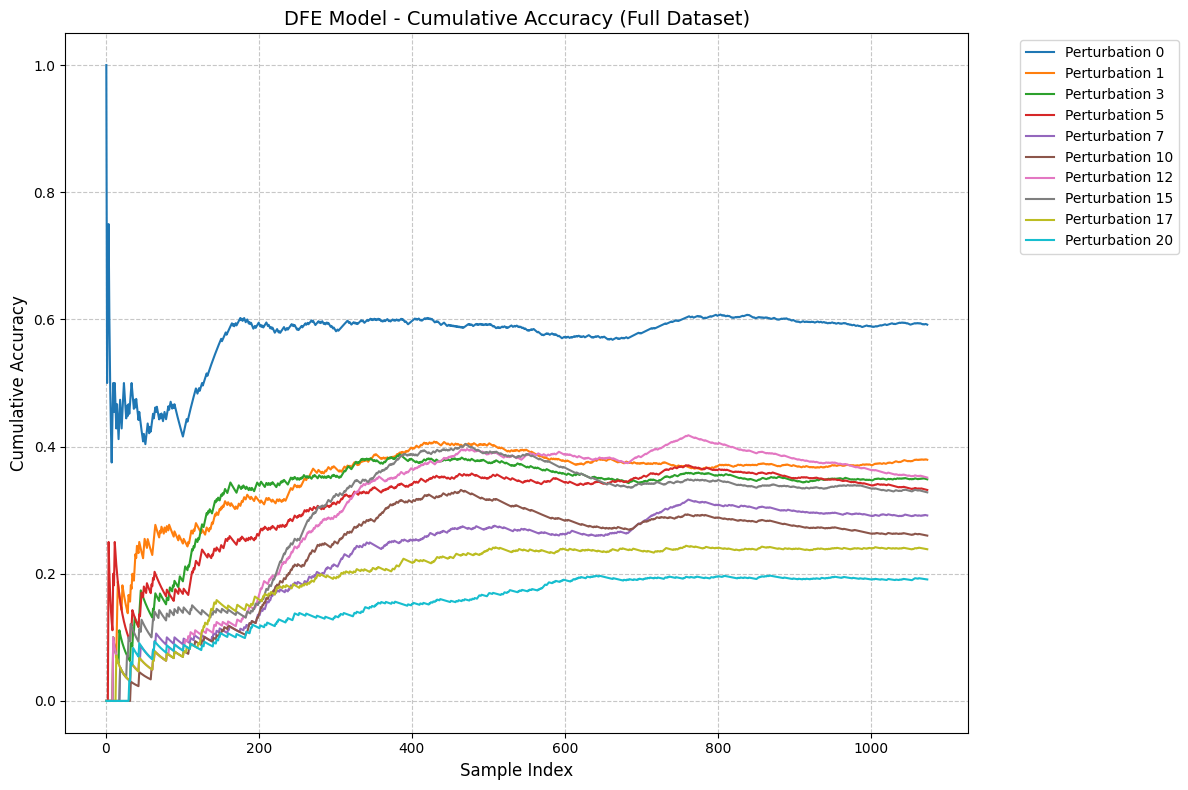

📊 Plot saved to: Results/DFE_cumulative_accuracy_full.png


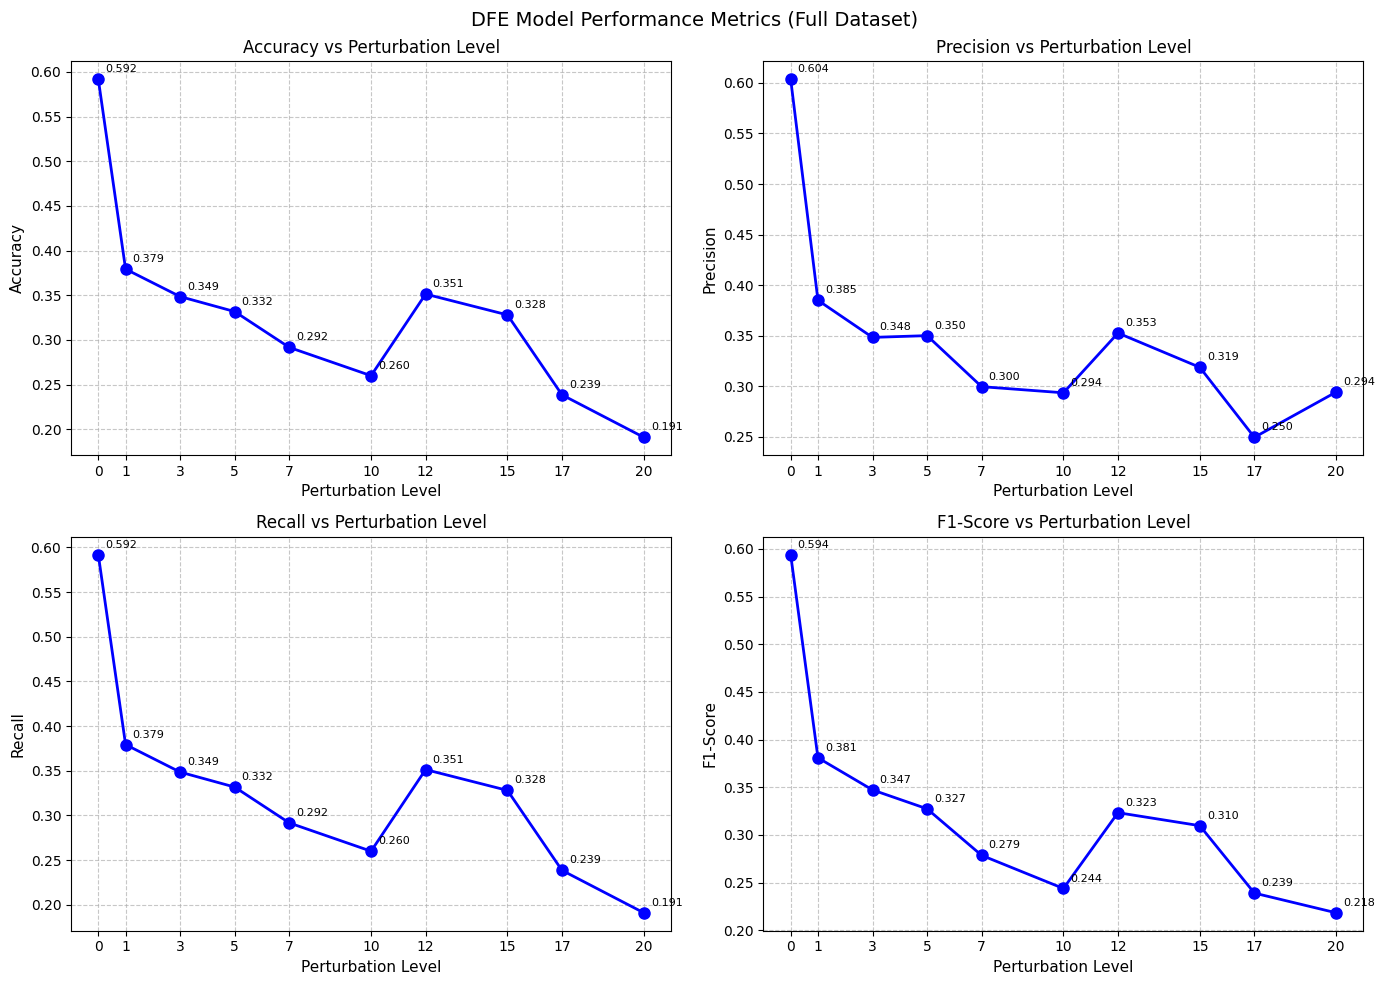

📊 Metrics comparison plot saved to: Results/DFE_metrics_comparison (Full Dataset).png

🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹
PART 2: Processing FIRST 100 samples only
🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹
CREATING CUMULATIVE ACCURACY CSV FILE

📂 Loading pre-trained DFE model...
📂 Loading model from Models/dfe_model.pth...
✅ Model loaded: 300 templates, 6 classes

📊 Processing perturbation levels:
------------------------------------------------------------

--- Perturbation Level 0 ---
  Using first 100 samples
  Computing cumulative accuracy for 100 samples...
  ✅ Cumulative accuracy done in 1.15s
  Final accuracy: 0.4200 (42.00%)
  Computing full metrics (Precision, Recall, F1)...
  ✅ Metrics computed in 0.38s
  📊 Accuracy:  0.4200
  📊 Precision: 1.0000
  📊 Recall:    0.4200
  📊 F1-Score:  0.5915

--- Perturbation Level 1 ---
  Using first 100 samples
  Computing cumulative accuracy for 100 samples...
  ✅ Cumulative accuracy done in 0.35s
  Final accuracy: 0.2500 (25.00%)
  Com

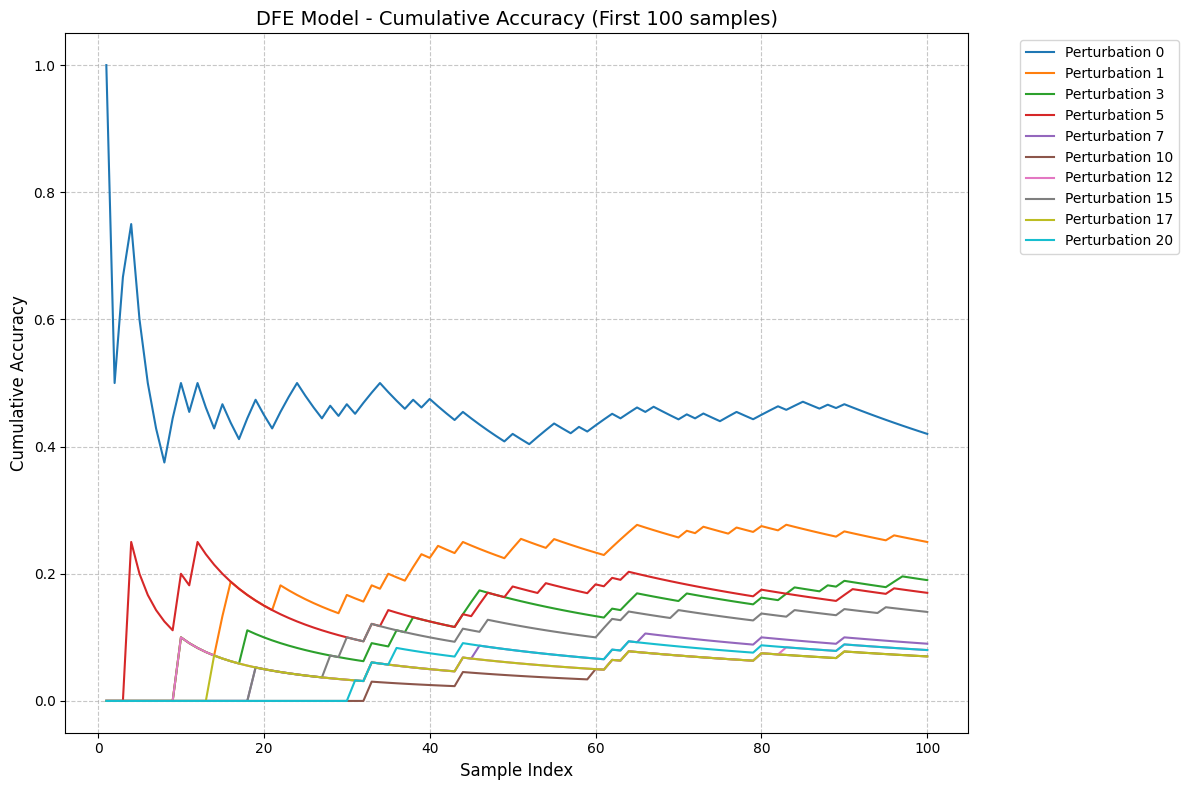

📊 Plot saved to: Results/DFE_cumulative_accuracy_first_100.png


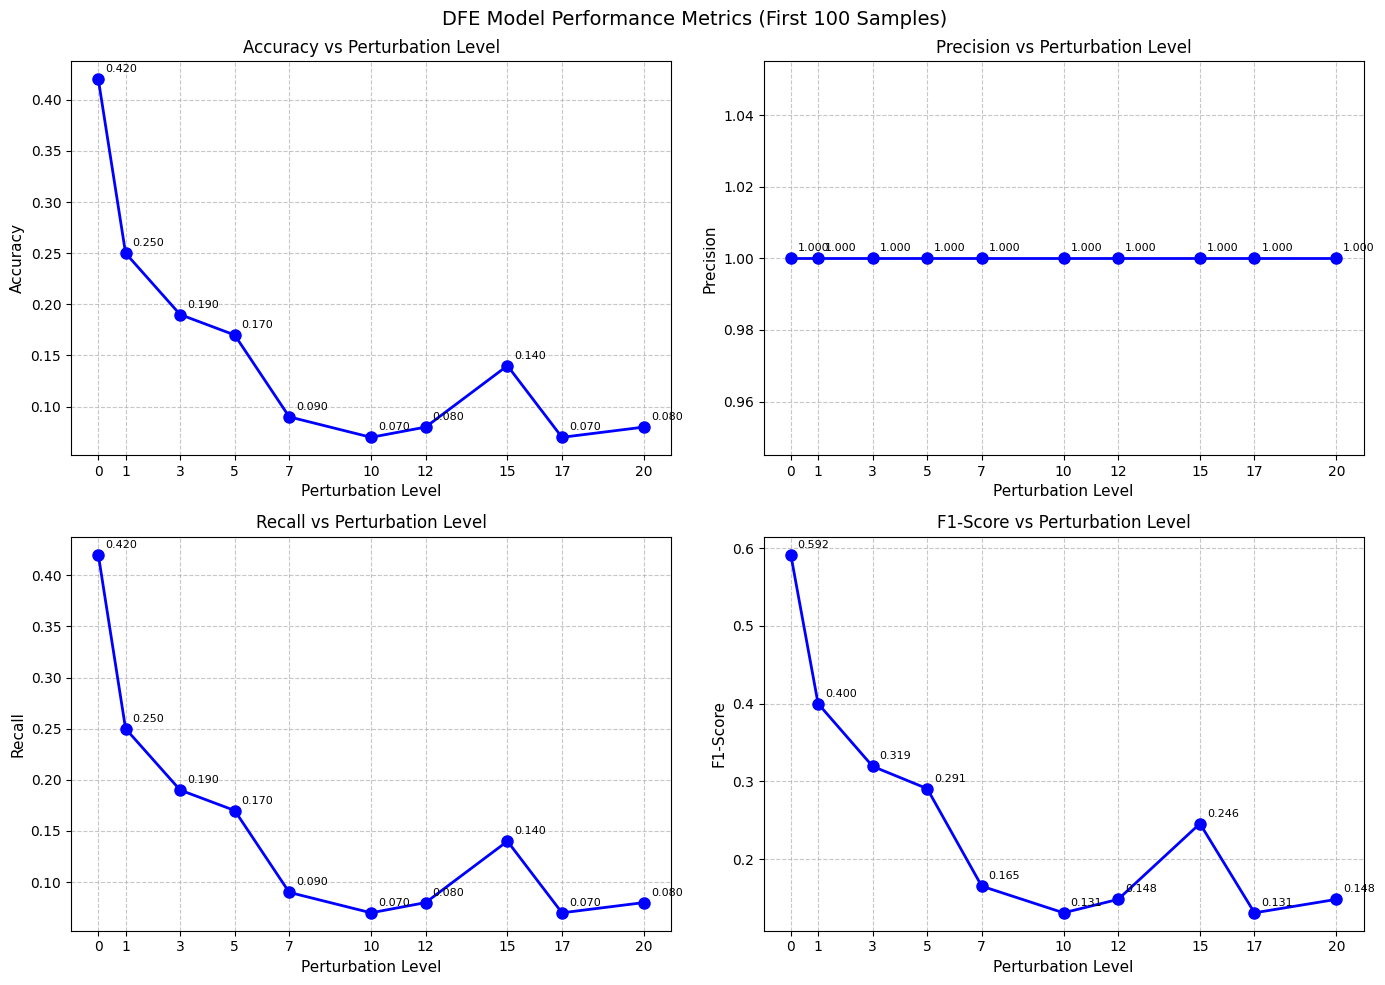

📊 Metrics comparison plot saved to: Results/DFE_metrics_comparison (First 100 Samples).png

SUMMARY - FINAL METRICS

📊 FULL DATASET METRICS:
 Perturbation Level Full_Accuracy Full_Precision Full_Recall Full_F1
                  0        0.5918         0.6036      0.5918  0.5938
                  1        0.3793         0.3851      0.3793  0.3809
                  3        0.3486         0.3484      0.3486  0.3472
                  5        0.3318         0.3502      0.3318  0.3274
                  7        0.2917         0.2997      0.2917  0.2786
                 10        0.2600         0.2937      0.2600  0.2438
                 12        0.3514         0.3527      0.3514  0.3233
                 15        0.3281         0.3188      0.3281  0.3097
                 17        0.2386         0.2497      0.2386  0.2390
                 20        0.1911         0.2944      0.1911  0.2183

📊 FIRST 100 SAMPLES METRICS:
 Perturbation Level First100_Accuracy First100_Precision First100_Reca

In [10]:
# ==================== CELL 2: ارزیابی مدل DFE روی داده‌های Burst با خروجی Cumulative Accuracy ====================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
import os
import time
import math
import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==================== تعریف کلاس‌های DFE ====================

class DFEBackbone(nn.Module):
    def __init__(self, input_channels=1, embedding_dim=256, input_features=81):
        super(DFEBackbone, self).__init__()
        self.input_features = input_features
        self.input_size = self._calculate_input_size(input_features)
        
        self.conv1 = nn.Conv2d(input_channels, 64, kernel_size=3, padding=1, stride=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=1, stride=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1, stride=2)
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1, stride=1)
        self.bn4 = nn.BatchNorm2d(64)
        
        self.conv5 = nn.Conv2d(64, 64, kernel_size=3, padding=1, stride=1)
        self.bn5 = nn.BatchNorm2d(64)
        
        self.conv6 = nn.Conv2d(64, 128, kernel_size=3, padding=1, stride=2)
        self.bn6 = nn.BatchNorm2d(128)
        self.conv7 = nn.Conv2d(128, 128, kernel_size=3, padding=1, stride=1)
        self.bn7 = nn.BatchNorm2d(128)
        
        self.conv8 = nn.Conv2d(128, 128, kernel_size=3, padding=1, stride=1)
        self.bn8 = nn.BatchNorm2d(128)
        self.conv9 = nn.Conv2d(128, 128, kernel_size=3, padding=1, stride=1)
        self.bn9 = nn.BatchNorm2d(128)
        
        self.conv10 = nn.Conv2d(128, 256, kernel_size=3, padding=1, stride=2)
        self.bn10 = nn.BatchNorm2d(256)
        self.conv11 = nn.Conv2d(256, 256, kernel_size=3, padding=1, stride=1)
        self.bn11 = nn.BatchNorm2d(256)
        self.conv12 = nn.Conv2d(256, 256, kernel_size=3, padding=1, stride=1)
        self.bn12 = nn.BatchNorm2d(256)
        self.conv13 = nn.Conv2d(256, 256, kernel_size=3, padding=1, stride=1)
        self.bn13 = nn.BatchNorm2d(256)
        
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc1 = nn.Linear(256, 256)
        self.fc2 = nn.Linear(256, embedding_dim)
        self.relu = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(0.5)
        
        self.res1 = nn.Sequential(nn.Conv2d(input_channels, 64, kernel_size=1, stride=1), nn.BatchNorm2d(64))
        self.res2 = nn.Sequential(nn.Conv2d(64, 64, kernel_size=1, stride=2), nn.BatchNorm2d(64))
        self.res4 = nn.Sequential(nn.Conv2d(64, 128, kernel_size=1, stride=2), nn.BatchNorm2d(128))
        self.res6 = nn.Sequential(nn.Conv2d(128, 256, kernel_size=1, stride=2), nn.BatchNorm2d(256))
        
        self._initialize_weights()
        
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
    
    def _calculate_input_size(self, num_features):
        sqrt = math.isqrt(num_features)
        if sqrt * sqrt == num_features:
            return sqrt
        return sqrt + 1
    
    def forward(self, x, return_features=False):
        features = []
        
        x1 = self.relu(self.bn1(self.conv1(x)))
        x1 = self.relu(self.bn2(self.conv2(x1)))
        x1 = x1 + self.res1(x)
        features.append(x1)
        
        x2 = self.relu(self.bn3(self.conv3(x1)))
        x2 = self.relu(self.bn4(self.conv4(x2)))
        x2 = x2 + self.res2(x1)
        features.append(x2)
        
        x3 = self.relu(self.bn5(self.conv5(x2)))
        x3 = x3 + x2
        features.append(x3)
        
        x4 = self.relu(self.bn6(self.conv6(x3)))
        x4 = self.relu(self.bn7(self.conv7(x4)))
        x4 = x4 + self.res4(x2)
        features.append(x4)
        
        x5 = self.relu(self.bn8(self.conv8(x4)))
        x5 = self.relu(self.bn9(self.conv9(x5)))
        x5 = x5 + x4
        features.append(x5)
        
        x6 = self.relu(self.bn10(self.conv10(x5)))
        x6 = self.relu(self.bn11(self.conv11(x6)))
        x6 = self.relu(self.bn12(self.conv12(x6)))
        x6 = self.relu(self.bn13(self.conv13(x6)))
        x6 = x6 + self.res6(x4)
        features.append(x6)
        
        x_pool = self.adaptive_pool(x6)
        x_pool = x_pool.view(x_pool.size(0), -1)
        embedding = self.relu(self.fc1(x_pool))
        embedding = self.dropout(embedding)
        embedding = self.fc2(embedding)
        
        if return_features:
            return embedding, features
        return embedding


class DFEComplete(nn.Module):
    def __init__(self, input_channels=1, embedding_dim=256, input_features=81):
        super(DFEComplete, self).__init__()
        self.backbone = DFEBackbone(input_channels, embedding_dim, input_features)
        
    def forward(self, x, return_features=False):
        if return_features:
            return self.backbone(x, return_features=True)
        return self.backbone(x)


class DFE:
    """
    کلاس اصلی DFE
    """
    def __init__(self, embedding_dim=256, k_neighbors=5):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.embedding_dim = embedding_dim
        self.k_neighbors = k_neighbors
        
        self.input_features = None
        self.input_size = None
        self.model = None
        self.template_library = []
        self.label_encoder = LabelEncoder()
        self.scaler = StandardScaler()
        
    def _calculate_input_size(self, num_features):
        sqrt = math.isqrt(num_features)
        if sqrt * sqrt == num_features:
            return sqrt
        return sqrt + 1
    
    def _pad_to_square(self, flat_vector, input_size):
        total_elements = input_size * input_size
        current_len = len(flat_vector)
        
        if current_len == total_elements:
            return flat_vector.reshape(1, input_size, input_size)
        elif current_len < total_elements:
            padded = np.pad(flat_vector, (0, total_elements - current_len), 'constant', constant_values=0)
            return padded.reshape(1, input_size, input_size)
        else:
            cut = flat_vector[:total_elements]
            return cut.reshape(1, input_size, input_size)
    
    def load_model(self, path='Models/dfe_model.pth'):
        """بارگذاری مدل آموزش دیده"""
        print(f"📂 Loading model from {path}...")
        
        if not os.path.exists(path):
            print(f"❌ Model file not found at {path}")
            print("Please train the model first using the training script.")
            return False
        
        try:
            checkpoint = torch.load(path, map_location=self.device, weights_only=False)
            
            self.input_features = checkpoint['input_features']
            self.input_size = checkpoint['input_size']
            
            self.model = DFEComplete(
                input_channels=1,
                embedding_dim=checkpoint['parameters']['embedding_dim'],
                input_features=self.input_features
            ).to(self.device)
            self.model.load_state_dict(checkpoint['model_state_dict'])
            self.model.eval()
            
            self.template_library = checkpoint['template_library']
            self.label_encoder.classes_ = checkpoint['label_encoder_classes']
            self.scaler.mean_ = checkpoint['scaler_mean']
            self.scaler.scale_ = checkpoint['scaler_scale']
            self.k_neighbors = checkpoint['parameters']['k_neighbors']
            
            print(f"✅ Model loaded: {len(self.template_library)} templates, {len(self.label_encoder.classes_)} classes")
            return True
            
        except Exception as e:
            print(f"❌ Error loading model: {e}")
            return False
    
    def predict_with_cumulative_accuracy(self, X, y):
        """
        پیش‌بینی نمونه به نمونه و محاسبه cumulative accuracy
        خروجی: لیستی از accuracy های تجمعی بعد از هر نمونه
        """
        self.model.eval()
        cumulative_accuracies = []
        correct_count = 0
        total_count = 0
        
        total_elements = self.input_size * self.input_size
        
        # پیش‌پردازش
        X_scaled = self.scaler.transform(X)
        y_encoded = self.label_encoder.transform(y)
        
        with torch.no_grad():
            for i in range(len(X_scaled)):
                # پردازش یک نمونه
                sample = X_scaled[i:i+1]
                square = self._pad_to_square(sample[0], self.input_size)
                X_tensor = torch.FloatTensor(np.array([square])).to(self.device)
                
                embedding = self.model(X_tensor).cpu().numpy()[0]
                
                # پیدا کردن نزدیک‌ترین قالب
                templates = np.array([t['emb'] for t in self.template_library])
                labels = np.array([t['label'] for t in self.template_library])
                
                dists = np.sqrt(np.sum((templates - embedding) ** 2, axis=1))
                k = min(self.k_neighbors, len(dists))
                k_indices = np.argpartition(dists, k)[:k]
                k_labels = labels[k_indices]
                
                unique_labels, counts = np.unique(k_labels, return_counts=True)
                pred = unique_labels[np.argmax(counts)]
                
                # بروزرسانی accuracy تجمعی
                if pred == y_encoded[i]:
                    correct_count += 1
                total_count += 1
                
                current_acc = correct_count / total_count
                cumulative_accuracies.append(current_acc)
        
        return cumulative_accuracies
    
    def predict_with_full_metrics(self, X, y):
        """
        پیش‌بینی تمام نمونه‌ها و محاسبه metrics کامل
        خروجی: predictions, accuracy, precision, recall, f1, confusion_matrix
        """
        self.model.eval()
        all_predictions = []
        all_true_labels = []
        
        total_elements = self.input_size * self.input_size
        
        # پیش‌پردازش
        X_scaled = self.scaler.transform(X)
        y_encoded = self.label_encoder.transform(y)
        
        with torch.no_grad():
            for i in range(len(X_scaled)):
                # پردازش یک نمونه
                sample = X_scaled[i:i+1]
                square = self._pad_to_square(sample[0], self.input_size)
                X_tensor = torch.FloatTensor(np.array([square])).to(self.device)
                
                embedding = self.model(X_tensor).cpu().numpy()[0]
                
                # پیدا کردن نزدیک‌ترین قالب
                templates = np.array([t['emb'] for t in self.template_library])
                labels = np.array([t['label'] for t in self.template_library])
                
                dists = np.sqrt(np.sum((templates - embedding) ** 2, axis=1))
                k = min(self.k_neighbors, len(dists))
                k_indices = np.argpartition(dists, k)[:k]
                k_labels = labels[k_indices]
                
                unique_labels, counts = np.unique(k_labels, return_counts=True)
                pred = unique_labels[np.argmax(counts)]
                
                all_predictions.append(pred)
                all_true_labels.append(y_encoded[i])
        
        # تبدیل به numpy array
        all_predictions = np.array(all_predictions)
        all_true_labels = np.array(all_true_labels)
        
        # محاسبه metrics
        accuracy = accuracy_score(all_true_labels, all_predictions)
        
        # برای محاسبه precision, recall, f1 با average='weighted' برای داده‌های چندکلاسه
        precision = precision_score(all_true_labels, all_predictions, average='weighted', zero_division=0)
        recall = recall_score(all_true_labels, all_predictions, average='weighted', zero_division=0)
        f1 = f1_score(all_true_labels, all_predictions, average='weighted', zero_division=0)
        
        # محاسبه confusion matrix
        cm = confusion_matrix(all_true_labels, all_predictions)
        
        return {
            'predictions': all_predictions,
            'true_labels': all_true_labels,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'confusion_matrix': cm
        }


# ==================== توابع کمکی برای ارزیابی ====================

def load_burst_data(base_path='../Dataset/AdvBurst_FTSC-IAT', perturb_level=0):
    """بارگذاری داده‌های Burst"""
    file_path = f'{base_path}/AdvBurstTrainedBurst_size_{perturb_level}_Step_2000.csv'
    
    if not os.path.exists(file_path):
        print(f"⚠️ File not found: {file_path}")
        return None, None
    
    df = pd.read_csv(file_path)
    X = df.iloc[:, :-1].values.astype(np.float32)
    y = df.iloc[:, -1].values
    
    return X, y


def create_cumulative_accuracy_csv(model_path='Models/dfe_model.pth',
                                    burst_base_path='../Dataset/AdvBurst_FTSC-IAT',
                                    test_perturb_levels=[0, 1, 3, 5, 7, 10, 12, 15, 17, 20],
                                    max_samples=None):
    """
    ایجاد فایل CSV با cumulative accuracy برای سطوح اختلال مختلف
    
    فرمت خروجی (درست - فقط 11 سطر):
    - سطر اول: Sample Index, 1, 2, 3, ..., N (شماره نمونه‌ها)
    - سطر دوم به بعد: هر سطر مربوط به یک سطح اختلال
    - ستون اول: نام سطح اختلال
    - ستون‌های بعدی: cumulative accuracy برای هر نمونه
    
    یعنی جدول TRANSPOSE شده است!
    """
    
    print("="*80)
    print("CREATING CUMULATIVE ACCURACY CSV FILE")
    print("="*80)
    
    # بررسی وجود مدل
    if not os.path.exists(model_path):
        print(f"\n❌ Model not found at {model_path}")
        print("Please train the base model first.")
        return None, None, None
    
    # بارگذاری مدل
    print("\n📂 Loading pre-trained DFE model...")
    dfe = DFE(k_neighbors=5)
    if not dfe.load_model(model_path):
        print("❌ Failed to load model")
        return None, None, None
    
    # دیکشنری برای ذخیره cumulative accuracy ها
    all_cumulative_accuracies = {}
    
    # دیکشنری برای ذخیره metrics کامل
    all_metrics = {}
    
    print("\n📊 Processing perturbation levels:")
    print("-" * 60)
    
    for perturb_level in test_perturb_levels:
        print(f"\n--- Perturbation Level {perturb_level} ---")
        
        X_burst, y_burst = load_burst_data(burst_base_path, perturb_level)
        
        if X_burst is None:
            print(f"  ⚠️ Data not found")
            continue
        
        # محدود کردن تعداد نمونه در صورت نیاز
        if max_samples and len(X_burst) > max_samples:
            X_burst = X_burst[:max_samples]
            y_burst = y_burst[:max_samples]
            print(f"  Using first {max_samples} samples")
        
        # محاسبه cumulative accuracy
        print(f"  Computing cumulative accuracy for {len(X_burst)} samples...")
        start_time = time.time()
        
        cumulative_acc = dfe.predict_with_cumulative_accuracy(X_burst, y_burst)
        
        elapsed = time.time() - start_time
        print(f"  ✅ Cumulative accuracy done in {elapsed:.2f}s")
        print(f"  Final accuracy: {cumulative_acc[-1]:.4f} ({cumulative_acc[-1]*100:.2f}%)")
        
        # محاسبه metrics کامل
        print(f"  Computing full metrics (Precision, Recall, F1)...")
        start_time = time.time()
        
        metrics = dfe.predict_with_full_metrics(X_burst, y_burst)
        
        elapsed = time.time() - start_time
        print(f"  ✅ Metrics computed in {elapsed:.2f}s")
        print(f"  📊 Accuracy:  {metrics['accuracy']:.4f}")
        print(f"  📊 Precision: {metrics['precision']:.4f}")
        print(f"  📊 Recall:    {metrics['recall']:.4f}")
        print(f"  📊 F1-Score:  {metrics['f1_score']:.4f}")
        
        all_cumulative_accuracies[perturb_level] = cumulative_acc
        all_metrics[perturb_level] = metrics
    
    if len(all_cumulative_accuracies) == 0:
        print("\n❌ No data was successfully loaded!")
        return None, None, None
    
    # تعیین حداکثر تعداد نمونه
    max_length = 0
    for acc_list in all_cumulative_accuracies.values():
        max_length = max(max_length, len(acc_list))
    
    # ساخت DataFrame به فرمت TRANSPOSE (سطوح اختلال در سطرها، نمونه‌ها در ستون‌ها)
    print("\n" + "="*60)
    print("CREATING CSV FILE (Transposed Format)")
    print("="*60)
    print("Format: Each ROW = a perturbation level, Each COLUMN = a sample number")
    print(f"Total rows: {len(test_perturb_levels) + 1} (1 header + {len(test_perturb_levels)} perturbations)")
    print(f"Total columns: {max_length + 1} (1 Sample Index column + {max_length} samples)")
    
    # ساختن داده برای DataFrame ترانسپوز شده
    # ستون اول: Sample Index (که همان سطوح اختلال هستند)
    # ستون‌های بعدی: شماره نمونه‌ها (1, 2, 3, ...)
    
    data_for_df = {}
    
    # ستون اول: Sample Index (نام سطوح اختلال)
    data_for_df['Sample Index'] = [level for level in test_perturb_levels if level in all_cumulative_accuracies]
    
    # برای هر نمونه (ستون)، مقادیر cumulative accuracy را از هر سطح اختلال جمع‌آوری کن
    for sample_idx in range(1, max_length + 1):
        col_name = str(sample_idx)  # نام ستون = شماره نمونه
        values = []
        for level in test_perturb_levels:
            if level in all_cumulative_accuracies:
                acc_list = all_cumulative_accuracies[level]
                if sample_idx <= len(acc_list):
                    values.append(acc_list[sample_idx - 1])
                else:
                    values.append(np.nan)
            else:
                values.append(np.nan)
        data_for_df[col_name] = values
    
    # ایجاد DataFrame
    df_cumulative = pd.DataFrame(data_for_df)
    
    # نمایش نمونه کوچک از DataFrame
    print("\n📊 Preview of CSV file (first 10 columns):")
    print("="*80)
    # نمایش ستون Sample Index و 5 ستون اول نمونه‌ها
    preview_cols = ['Sample Index'] + [str(i) for i in range(1, min(11, max_length + 1))]
    print(df_cumulative[preview_cols].head(10).to_string(index=False))
    
    print("\n📊 DataFrame Info:")
    print(f"   Shape: {df_cumulative.shape[0]} rows × {df_cumulative.shape[1]} columns")
    print(f"   Rows: {df_cumulative.shape[0]} (1 header row in CSV, but in DataFrame each row is a perturbation level)")
    print(f"   Columns: {df_cumulative.shape[1]} (Sample Index + {max_length} sample columns)")
    
    # ذخیره فایل کامل
    os.makedirs('Results', exist_ok=True)
    
    if max_samples:
        csv_filename = f'Results/DFE_cumulative_accuracy_first_{max_samples}.csv'
    else:
        csv_filename = 'Results/DFE_cumulative_accuracy_full.csv'
    
    df_cumulative.to_csv(csv_filename, index=False)
    print(f"\n💾 CSV saved to: {csv_filename}")
    
    # ذخیره metrics در فایل جداگانه
    metrics_data = []
    for perturb_level in test_perturb_levels:
        if perturb_level in all_metrics:
            m = all_metrics[perturb_level]
            metrics_data.append({
                'Perturbation Level': perturb_level,
                'Accuracy': m['accuracy'],
                'Precision': m['precision'],
                'Recall': m['recall'],
                'F1-Score': m['f1_score'],
                'Num Samples': len(m['predictions'])
            })
    
    if metrics_data:
        df_metrics = pd.DataFrame(metrics_data)
        if max_samples:
            metrics_filename = f'Results/DFE_metrics_first_{max_samples}.csv'
        else:
            metrics_filename = 'Results/DFE_metrics_full.csv'
        
        df_metrics.to_csv(metrics_filename, index=False)
        print(f"💾 Metrics saved to: {metrics_filename}")
    
    # نمایش اطلاعات آماری
    print("\n📊 Statistical Summary (Final metrics for each perturbation level):")
    print("-" * 80)
    print(f"{'Perturb':^10} {'Accuracy':^12} {'Precision':^12} {'Recall':^12} {'F1-Score':^12}")
    print("-" * 80)
    for perturb_level in test_perturb_levels:
        if perturb_level in all_metrics:
            m = all_metrics[perturb_level]
            print(f"{perturb_level:^10} {m['accuracy']:^12.4f} {m['precision']:^12.4f} {m['recall']:^12.4f} {m['f1_score']:^12.4f}")
    
    return df_cumulative, all_cumulative_accuracies, all_metrics


def plot_cumulative_accuracies(all_cumulative_accuracies, max_samples=None):
    """رسم نمودار cumulative accuracy"""
    import matplotlib.pyplot as plt
    
    if not all_cumulative_accuracies:
        print("No data to plot")
        return
    
    plt.figure(figsize=(12, 8))
    
    for perturb_level, accuracies in all_cumulative_accuracies.items():
        plt.plot(range(1, len(accuracies) + 1), accuracies, 
                 label=f'Perturbation {perturb_level}', linewidth=1.5)
    
    plt.xlabel('Sample Index', fontsize=12)
    plt.ylabel('Cumulative Accuracy', fontsize=12)
    
    if max_samples:
        plt.title(f'DFE Model - Cumulative Accuracy (First {max_samples} samples)', fontsize=14)
        plot_filename = f'Results/DFE_cumulative_accuracy_first_{max_samples}.png'
    else:
        plt.title('DFE Model - Cumulative Accuracy (Full Dataset)', fontsize=14)
        plot_filename = 'Results/DFE_cumulative_accuracy_full.png'
    
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(plot_filename, dpi=300)
    plt.show()
    
    print(f"📊 Plot saved to: {plot_filename}")


def plot_metrics_comparison(metrics_dict, title_suffix=""):
    """رسم نمودار مقایسه metrics برای سطوح مختلف اختلال"""
    import matplotlib.pyplot as plt
    
    if not metrics_dict:
        print("No metrics data to plot")
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    metrics_names = ['accuracy', 'precision', 'recall', 'f1_score']
    titles = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    
    levels = sorted(metrics_dict.keys())
    
    for idx, (metric, title) in enumerate(zip(metrics_names, titles)):
        ax = axes[idx // 2, idx % 2]
        
        values = [metrics_dict[level][metric] for level in levels]
        ax.plot(levels, values, marker='o', linewidth=2, markersize=8, color='blue')
        
        ax.set_xlabel('Perturbation Level', fontsize=11)
        ax.set_ylabel(title, fontsize=11)
        ax.set_title(f'{title} vs Perturbation Level', fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.7)
        ax.set_xticks(levels)
        
        # Add value labels on points
        for i, (l, v) in enumerate(zip(levels, values)):
            ax.annotate(f'{v:.3f}', (l, v), xytext=(5, 5), textcoords='offset points', fontsize=8)
    
    plt.suptitle(f'DFE Model Performance Metrics{title_suffix}', fontsize=14)
    plt.tight_layout()
    
    if title_suffix:
        plot_filename = f'Results/DFE_metrics_comparison{title_suffix}.png'
    else:
        plot_filename = 'Results/DFE_metrics_comparison.png'
    
    plt.savefig(plot_filename, dpi=300)
    plt.show()
    
    print(f"📊 Metrics comparison plot saved to: {plot_filename}")


# ==================== اجرای اصلی ====================

def run_evaluation():
    """اجرای کامل ارزیابی و ایجاد فایل‌های CSV"""
    
    TEST_PERTURB_LEVELS = [0, 1, 3, 5, 7, 10, 12, 15, 17, 20]
    
    print("="*80)
    print("DFE CUMULATIVE ACCURACY EVALUATION ON BURST DATASET")
    print("="*80)
    print(f"Perturbation levels: {TEST_PERTURB_LEVELS}")
    print("="*80)
    
    # ===== 1. ایجاد فایل برای تمام نمونه‌ها =====
    print("\n" + "🔹"*40)
    print("PART 1: Processing ALL samples")
    print("🔹"*40)
    
    df_full, acc_full, metrics_full = create_cumulative_accuracy_csv(
        model_path='Models/dfe_model.pth',
        burst_base_path='../Dataset/AdvBurst_FTSC-IAT',
        test_perturb_levels=TEST_PERTURB_LEVELS,
        max_samples=None  # تمام نمونه‌ها
    )
    
    if acc_full:
        plot_cumulative_accuracies(acc_full, max_samples=None)
        plot_metrics_comparison(metrics_full, " (Full Dataset)")
    
    # ===== 2. ایجاد فایل برای 100 نمونه اول =====
    print("\n" + "🔹"*40)
    print("PART 2: Processing FIRST 100 samples only")
    print("🔹"*40)
    
    df_100, acc_100, metrics_100 = create_cumulative_accuracy_csv(
        model_path='Models/dfe_model.pth',
        burst_base_path='../Dataset/AdvBurst_FTSC-IAT',
        test_perturb_levels=TEST_PERTURB_LEVELS,
        max_samples=100  # فقط 100 نمونه اول
    )
    
    if acc_100:
        plot_cumulative_accuracies(acc_100, max_samples=100)
        plot_metrics_comparison(metrics_100, " (First 100 Samples)")
    
    # ===== 3. نمایش خلاصه نتایج نهایی =====
    if metrics_full or metrics_100:
        print("\n" + "="*80)
        print("SUMMARY - FINAL METRICS")
        print("="*80)
        
        # ایجاد خلاصه جامع
        summary_data = []
        for level in TEST_PERTURB_LEVELS:
            row = {'Perturbation Level': level}
            
            if metrics_full and level in metrics_full:
                row['Full_Accuracy'] = f"{metrics_full[level]['accuracy']:.4f}"
                row['Full_Precision'] = f"{metrics_full[level]['precision']:.4f}"
                row['Full_Recall'] = f"{metrics_full[level]['recall']:.4f}"
                row['Full_F1'] = f"{metrics_full[level]['f1_score']:.4f}"
            else:
                row['Full_Accuracy'] = "N/A"
                row['Full_Precision'] = "N/A"
                row['Full_Recall'] = "N/A"
                row['Full_F1'] = "N/A"
            
            if metrics_100 and level in metrics_100:
                row['First100_Accuracy'] = f"{metrics_100[level]['accuracy']:.4f}"
                row['First100_Precision'] = f"{metrics_100[level]['precision']:.4f}"
                row['First100_Recall'] = f"{metrics_100[level]['recall']:.4f}"
                row['First100_F1'] = f"{metrics_100[level]['f1_score']:.4f}"
            else:
                row['First100_Accuracy'] = "N/A"
                row['First100_Precision'] = "N/A"
                row['First100_Recall'] = "N/A"
                row['First100_F1'] = "N/A"
            
            summary_data.append(row)
        
        df_summary = pd.DataFrame(summary_data)
        
        if metrics_full:
            print("\n📊 FULL DATASET METRICS:")
            print(df_summary[['Perturbation Level', 'Full_Accuracy', 'Full_Precision', 'Full_Recall', 'Full_F1']].to_string(index=False))
        
        if metrics_100:
            print("\n📊 FIRST 100 SAMPLES METRICS:")
            print(df_summary[['Perturbation Level', 'First100_Accuracy', 'First100_Precision', 'First100_Recall', 'First100_F1']].to_string(index=False))
        
        # ذخیره خلاصه جامع
        df_summary.to_csv('Results/DFE_complete_summary.csv', index=False)
        print("\n💾 Complete summary saved to: Results/DFE_complete_summary.csv")
        
        # نمایش confusion matrix برای سطح اختلال 0 (بدون نویز)
        if metrics_full and 0 in metrics_full:
            print("\n" + "="*80)
            print("CONFUSION MATRIX FOR PERTURBATION LEVEL 0 (No Noise)")
            print("="*80)
            cm = metrics_full[0]['confusion_matrix']
            print(f"Confusion Matrix shape: {cm.shape}")
            print("\nFirst 10x10 of confusion matrix (if large):")
            if cm.shape[0] > 10:
                print(pd.DataFrame(cm[:10, :10]))
            else:
                print(pd.DataFrame(cm))
            
            # ذخیره confusion matrix کامل
            cm_df = pd.DataFrame(cm)
            cm_df.to_csv('Results/DFE_confusion_matrix_level0.csv', index=False)
            print("\n💾 Full confusion matrix saved to: Results/DFE_confusion_matrix_level0.csv")
    
    print("\n" + "="*80)
    print("✅ EVALUATION COMPLETE")
    print("="*80)
    
    if metrics_full or metrics_100:
        print("\n📁 Generated files:")
        if metrics_full:
            print("  1. Results/DFE_cumulative_accuracy_full.csv - ALL samples")
            print("  2. Results/DFE_metrics_full.csv - Metrics for ALL samples")
            print("  3. Results/DFE_cumulative_accuracy_full.png - Plot (all samples)")
            print("  4. Results/DFE_metrics_comparison (Full Dataset).png - Metrics comparison")
        if metrics_100:
            print("  5. Results/DFE_cumulative_accuracy_first_100.csv - First 100 samples")
            print("  6. Results/DFE_metrics_first_100.csv - Metrics for first 100 samples")
            print("  7. Results/DFE_cumulative_accuracy_first_100.png - Plot (first 100)")
            print("  8. Results/DFE_metrics_comparison (First 100 Samples).png - Metrics comparison")
        print("  9. Results/DFE_complete_summary.csv - Complete summary")
        if metrics_full and 0 in metrics_full:
            print(" 10. Results/DFE_confusion_matrix_level0.csv - Confusion matrix (level 0)")
    else:
        print("\n❌ No results were generated. Please check:")
        print("  1. Model file exists at 'Models/dfe_model.pth'")
        print("  2. Data files exist in 'AdvBurst_FTSC-IAT/' directory")
        print("  3. File permissions are correct")
    
    return df_full, df_100, metrics_full, metrics_100


# اجرا
if __name__ == "__main__":
    df_full, df_100, metrics_full, metrics_100 = run_evaluation()